# ハミルトニアンシミュレーションの回路資源比較

Trotter–Suzuki、QSVT、multiproduct formula (MPF) を、同じ Pauli 和と誤差予算の下で比較します。小規模系では実際の statevector、大規模系では密行列を作らないゲート分解モデルを使います。

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from hamiltonian_resources import (
    BenchmarkConfig, benchmark_scaling, build_hamiltonian_qsvt_circuit,
    build_multiproduct_circuit, build_trotter_circuit, compare_with_exact,
    estimate_qsvt_degree, transverse_field_ising,
)
pd.set_option("display.max_columns", None)

## 1. ハミルトニアン入力

例として $H=-J\sum_i Z_iZ_{i+1}-h\sum_iX_i$ を使います。Qiskit の Pauli label は右端が qubit 0 です。任意の Pauli 和は `PauliHamiltonian.from_terms` で渡せます。

In [2]:
H = transverse_field_ising(3, coupling=1.0, field=0.7)
print(H.name, H.terms)
print(f"terms={H.term_count}, alpha=sum|h_j|={H.alpha:.3f}")

TFIM-3 (('IZZ', -1.0), ('ZZI', -1.0), ('IIX', -0.7), ('IXI', -0.7), ('XII', -0.7))
terms=5, alpha=sum|h_j|=4.100


## 2. 実回路を構成する

下の関数はいずれも Hamiltonian の密行列を指数化しません。QSVTは時刻と許容誤差からcosine/sine位相を合成し、MPFは既定の`new` scheduleでsegmentごとのrobust OAAを構成します。

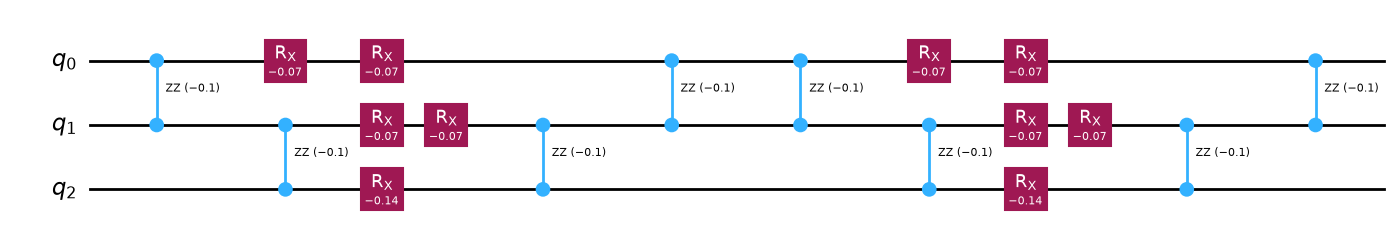

MPF metadata: {'algorithm': 'multiproduct', 'construction': 'robust-oaa-segments', 'm': 2, 'schedule': 'new', 'exponents': (1, 2), 'exponent_sum': 3, 'segments': 1, 'step_time': 0.2, 'coefficients': [-0.3333333333333333, 1.3333333333333333], 'coefficient_l1_norm': 1.6666666666666665, 'padding_weight': 0.3333333333333335, 'lcu_normalization': 2.0, 'formal_order': 4, 'amplitude_amplification': True, 'good_subspace': 'branch register all-zero', 'postselection': 'measure branch register as all-zero', 'trotter_step_queries_per_segment': 9, 'trotter_step_queries': 9, 'base_lcu_uses_per_segment': 3, 'logical_gate_counts_per_segment': {'prepare': 6, 'select': 3, 'good_reflection': 2, 'controlled_u2': 9}, 'logical_gate_counts': {'prepare': 6, 'select': 3, 'good_reflection': 2, 'controlled_u2': 9}, 'registers': {'branch': 2, 'system': 3}}
QSVT metadata: {'algorithm': 'qsvt-hamiltonian-simulation', 'construction': 'explicit-cos-sin-lcu', 'cosine_degree': 4, 'sine_degree': 5, 'alpha': 4.1, 'alpha_

In [3]:
time = 0.2
trotter_circuit = build_trotter_circuit(H, time, reps=2, order=2)
mpf_circuit = build_multiproduct_circuit(H, time, m=2, segments=1)
qsvt_circuit = build_hamiltonian_qsvt_circuit(H, time, epsilon=1e-2)

display(trotter_circuit.draw(output="mpl", fold=30))
print("MPF metadata:", mpf_circuit.metadata)
print("QSVT metadata:", qsvt_circuit.metadata)

## 3. 小規模系で厳密解と比較

MPF は branch=0 への postselection 後の fidelity と成功確率を別々に表示します。

In [4]:
validation = []
for reps in (1, 2, 4, 8):
    row = compare_with_exact(H, time, method="trotter", reps=reps, trotter_order=2)
    row["segments"] = reps
    validation.append(row)
for reps in (1, 2, 4):
    row = compare_with_exact(H, time, method="multiproduct", reps=reps, mpf_m=2)
    row["segments"] = reps
    validation.append(row)
pd.DataFrame(validation)

,method,state_error,fidelity,success_probability,segments
0,trotter,5.556782e-03,0.999969,1.0,1
1,trotter,1.371851e-03,0.999998,1.0,2
2,trotter,3.418888e-04,1.000000,1.0,4
3,trotter,8.540525e-05,1.000000,1.0,8
4,multiproduct,2.967284e-05,1.000000,1.0,1
5,multiproduct,1.827086e-06,1.000000,1.0,2
6,multiproduct,1.138048e-07,1.000000,1.0,4


## 4. 固定誤差でシステムサイズを拡大

`transpile_circuits=False` は回路をシミュレーションせず、明示された分解モデルから数えます。`parameter` は Trotter の反復数、MPF の segment 数、QSVT の次数です。T 数には任意角回転の近似合成コストを含めます。

In [5]:
config = BenchmarkConfig(
    time=0.5, target_error=1e-3, synthesis_error_fraction=0.1,
    trotter_order=2, mpf_m=3, mpf_schedule="new",
)
sizes = list(range(2, 31, 2))
resources = benchmark_scaling(
    sizes, lambda n: transverse_field_ising(n, field=0.7), config,
    transpile_circuits=False,
)
resources.head(9)

,algorithm,num_qubits,cnot_count,t_count,rotation_count,depth,counting_mode,rotation_synthesis_error,system_size,alpha,target_error,lcu_scale,nominal_success_probability,parameter
0,trotter,2,147,14960,220,-1,analytical-model,0.0001,2,2.4,0.001,1.0,1.00,44
1,multiproduct,4,1964,40752,566,-1,analytical-model,0.0001,2,2.4,0.001,2.0,1.00,4
2,qsvt,5,792,14280,210,-1,analytical-model,0.0001,2,2.4,0.001,2.0,0.25,7
3,trotter,4,1839,167310,2145,-1,analytical-model,0.0001,4,5.8,0.001,1.0,1.00,165
4,multiproduct,6,17164,354294,4374,-1,analytical-model,0.0001,4,5.8,0.001,2.0,1.00,12
5,qsvt,8,4128,41040,570,-1,analytical-model,0.0001,4,5.8,0.001,2.0,0.25,9
6,trotter,6,6281,573447,6909,-1,analytical-model,0.0001,6,9.2,0.001,1.0,1.00,329
7,multiproduct,8,47579,1011876,11766,-1,analytical-model,0.0001,6,9.2,0.001,2.0,1.00,20
8,qsvt,11,13784,128898,1674,-1,analytical-model,0.0001,6,9.2,0.001,2.0,0.25,13


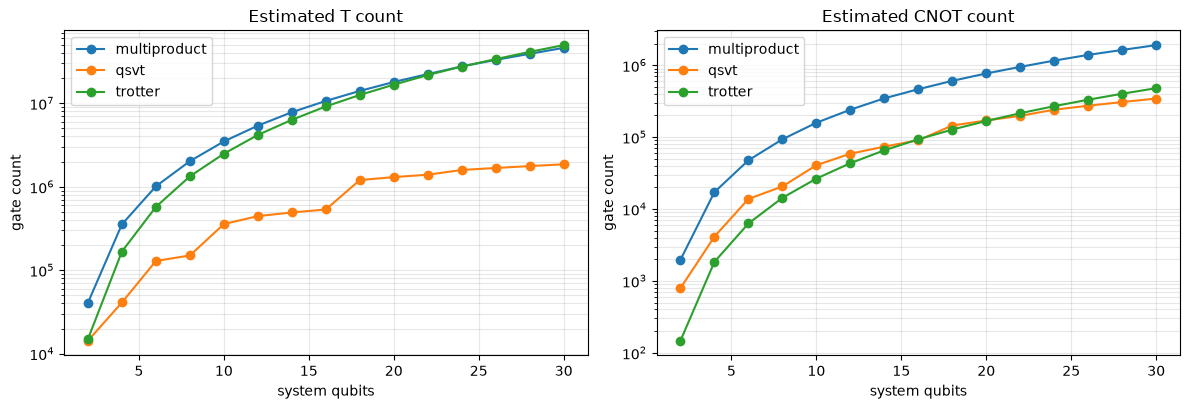

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for algorithm, group in resources.groupby("algorithm"):
    axes[0].plot(group.system_size, group.t_count, marker="o", label=algorithm)
    axes[1].plot(group.system_size, group.cnot_count, marker="o", label=algorithm)
for ax, title in zip(axes, ("Estimated T count", "Estimated CNOT count")):
    ax.set_yscale("log")
    ax.set_xlabel("system qubits")
    ax.set_ylabel("gate count")
    ax.set_title(title)
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()
plt.tight_layout()

## 5. 小規模で解析モデルを transpile 値に校正

実回路の多重制御分解は急速に大きくなります。まず緩い誤差・2 qubit で試し、その後に範囲を広げてください。

In [7]:
small_config = BenchmarkConfig(time=0.05, target_error=0.2, mpf_m=2)
compiled = benchmark_scaling(
    [2], transverse_field_ising, small_config, transpile_circuits=True
)
compiled[["algorithm", "num_qubits", "t_count", "cnot_count", "depth"]]

,algorithm,num_qubits,t_count,cnot_count,depth
0,trotter,2,104,4,11
1,multiproduct,4,39150,814,1839
2,qsvt,6,2768304,89668,191028


### 解釈上の注意

- QSVT の PREPARE/SELECT コストは Hamiltonian の入力モデルに強く依存します。ここでは一般の Pauli-LCU を公平に数えています。
- MPFの具体回路はsegmentごとの3-step OAAを含みます。既定の解析式はpadding、branch幅、OAA定数を完全には反映しないlegacy modelです。
- `choose_parameters` は共通の保守的 error proxy です。論文レベルの比較では、対象 Hamiltonian の交換関係を含む厳密上界または小規模校正値に置き換えてください。
- QSVT の完全な $e^{-iHt}$ は cosine と sine の二つの definite-parity 列の coherent LCU を要します。`build_hamiltonian_qsvt_circuit` がこの結合回路を構成します。